In [1]:
import pandas as pd

df = pd.read_csv("dataset_penjualan_mobil_600_baris.csv")
df

,Tanggal,Kota,Merek,Model,Tahun,Harga_Juta,Metode_Pembayaran,Status_Penjualan
0,2025-02-20,Medan,Mitsubishi,Pajero Sport,2024,199,Cash,Terjual
1,2023-08-21,Bandung,Mitsubishi,Pajero Sport,2023,136,Cash,Pending
2,2024-09-29,Jakarta,Daihatsu,Sigra,2023,626,Leasing,Batal
3,2025-04-19,Makassar,Mitsubishi,Pajero Sport,2022,340,Leasing,Pending
4,2024-05-07,Surabaya,Toyota,Raize,2020,159,Leasing,Batal
...,...,...,...,...,...,...,...,...
595,2023-06-29,Surabaya,Mitsubishi,Pajero Sport,2022,520,Cash,Batal
596,2024-10-22,Yogyakarta,Suzuki,Ertiga,2024,267,Leasing,Terjual
597,2023-12-03,Surabaya,Mitsubishi,Xpander,2024,201,Kredit,Pending
598,2023-09-14,Makassar,Suzuki,Ertiga,2018,253,Kredit,Terjual


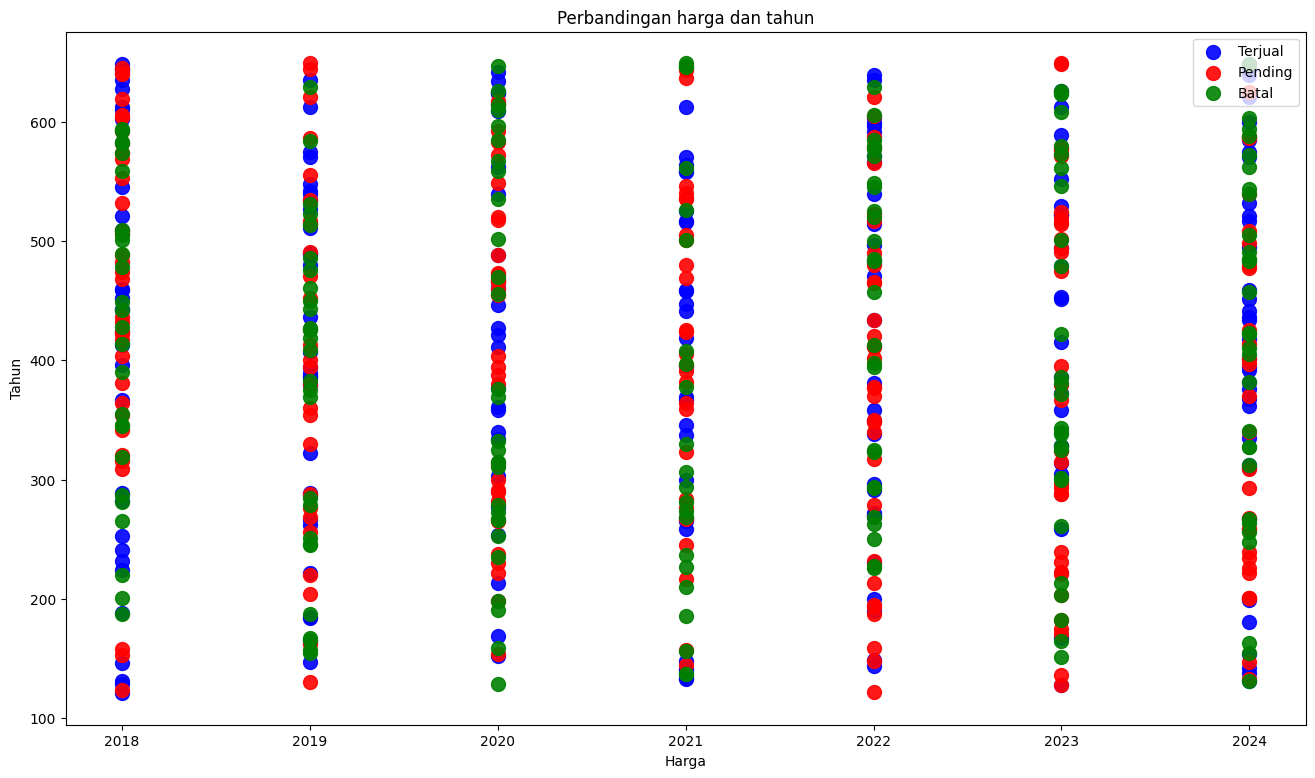

In [11]:
import matplotlib.pyplot as plt

Terjual = df[df["Status_Penjualan"]=="Terjual"]
Pending = df[df["Status_Penjualan"]=="Pending"]
Batal = df[df["Status_Penjualan"]=="Batal"]

plt.figure(figsize=(16,9))

plt.scatter(Terjual["Tahun"], Terjual["Harga_Juta"], s=100, alpha=0.9, color="blue", label="Terjual")
plt.scatter(Pending["Tahun"], Pending["Harga_Juta"], s=100, alpha=0.9, color="red", label="Pending")
plt.scatter(Batal["Tahun"], Batal["Harga_Juta"], s=100, alpha=0.9, color="green", label="Batal")
plt.ylabel("Tahun")
plt.xlabel("Harga")
plt.title("Perbandingan harga dan tahun")
plt.legend()

plt.show()

In [5]:
df["Status_Penjualan"].unique()

array(['Terjual', 'Pending', 'Batal'], dtype=object)

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

X = df[["Kota","Merek","Model","Tahun","Harga_Juta","Metode_Pembayaran"]]
y = df["Status_Penjualan"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_columns = ["Tahun","Harga_Juta"]
categorical_columns = ["Kota","Merek","Model","Metode_Pembayaran"]

preprocessing = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(), numeric_columns),
        ("ohe", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

model = Pipeline(
    steps=[
        ("preprocessing", preprocessing),
        ("model", LogisticRegression())
    ]
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("accuracy :", accuracy_score(y_test, y_pred))
print("\nClassification Report :\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix :\n", confusion_matrix(y_test, y_pred))

accuracy : 0.31666666666666665

Classification Report :
               precision    recall  f1-score   support

       Batal       0.32      0.21      0.26        47
     Pending       0.30      0.50      0.38        34
     Terjual       0.33      0.28      0.31        39

    accuracy                           0.32       120
   macro avg       0.32      0.33      0.31       120
weighted avg       0.32      0.32      0.31       120


Confusion Matrix :
 [[10 23 14]
 [ 9 17  8]
 [12 16 11]]


In [24]:
data_baru = pd.DataFrame([["Surabaya","Mitsubishi","Pajero Sport", 2022, 520, "Cash"]],
                       columns=["Kota","Merek","Model","Tahun","Harga_Juta","Metode_Pembayaran"])
prediksi = model.predict(data_baru)[0]
presentase = max(model.predict_proba(data_baru)[0])
print(f"model memprediksi {prediksi} dengan tingkat keyakinan {presentase*100:.2f}%")

model memprediksi Terjual dengan tingkat keyakinan 53.75%


In [25]:
import joblib

joblib.dump(model, "fadhil1.joblib")

['fadhil1.joblib']